<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-48-bagging-intuition-theory-code?scriptVersionId=350332782" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🛍️ ML 48 — Bagging | Intuition, Theory & Code

# Importing Libraries

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier

from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions

from sklearn.metrics import accuracy_score

# Reading Data

In [3]:
df = pd.read_csv('/kaggle/input/datasets/uciml/iris/Iris.csv',
                usecols=lambda column: column not in ["Id"])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# Label Encoding

In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Species'] = encoder.fit_transform(df['Species'])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


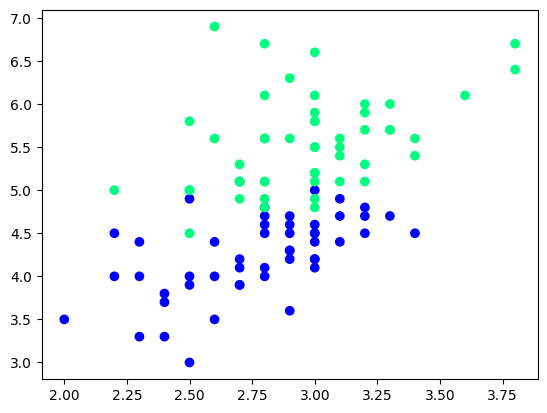

In [6]:
plt.scatter(df['SepalWidthCm'], df['PetalLengthCm'], c=df['Species'], cmap='winter')
plt.show()

# Bagging from Scratch

In [7]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [8]:
df_train

,SepalWidthCm,PetalLengthCm,Species
69,2.5,3.9,1
64,2.9,3.6,1
140,3.1,5.6,2
80,2.4,3.8,1
110,3.2,5.1,2
120,3.2,5.7,2
149,3.0,5.1,2
82,2.7,3.9,1
137,3.1,5.5,2
85,3.4,4.5,1


In [9]:
df_val

,SepalWidthCm,PetalLengthCm,Species
138,3.0,4.8,2
71,2.8,4.0,1
100,3.3,6.0,2
86,3.1,4.7,1
125,3.2,6.0,2


In [10]:
df_test

,SepalWidthCm,PetalLengthCm,Species
118,2.6,6.9,2
73,2.8,4.7,1
55,2.8,4.5,1
56,3.3,4.7,1
72,2.5,4.9,1


In [11]:
X_test = df_val.drop(columns=['Species'])
y_test = df_val.Species

In [12]:
y_test

138    2
71     1
100    2
86     1
125    2
Name: Species, dtype: int64

# Case 1 - Bagging

In [13]:
# Data for Tree 1
df_bag1 = df_train.sample(8, replace=True)

X = df_bag1.drop(columns=['Species'])
y = df_bag1.Species

df_bag1

,SepalWidthCm,PetalLengthCm,Species
80,2.4,3.8,1
80,2.4,3.8,1
64,2.9,3.6,1
82,2.7,3.9,1
85,3.4,4.5,1
85,3.4,4.5,1
149,3.0,5.1,2
149,3.0,5.1,2


In [14]:
def evaluate(clf, X, y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

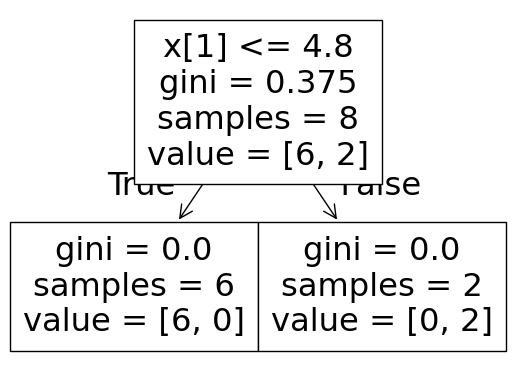

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


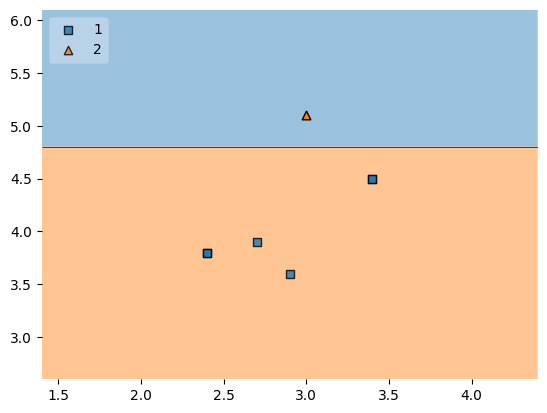

In [15]:
dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1, X, y)

In [16]:
# Data for Tree 1
df_bag2 = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag2.drop(columns=['Species'])
y = df_bag2.Species

# print df_bag
df_bag2

,SepalWidthCm,PetalLengthCm,Species
110,3.2,5.1,2
64,2.9,3.6,1
85,3.4,4.5,1
149,3.0,5.1,2
137,3.1,5.5,2
110,3.2,5.1,2
64,2.9,3.6,1
85,3.4,4.5,1


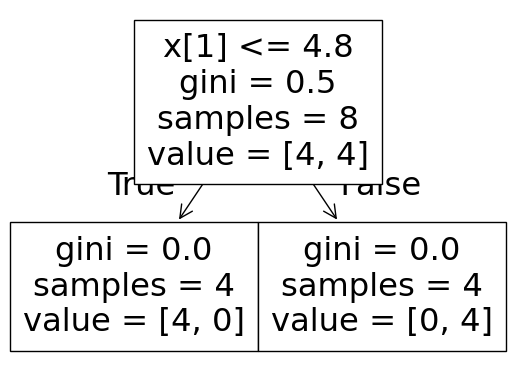

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


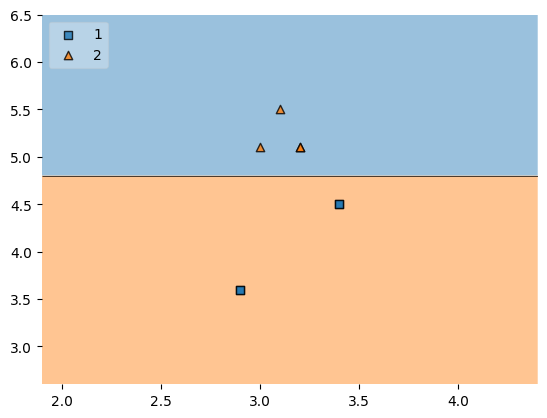

In [17]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [18]:
# Data for Tree 3
df_bag3 = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag3.drop(columns=['Species'])
y = df_bag3.Species

# print df_bag
df_bag3

,SepalWidthCm,PetalLengthCm,Species
137,3.1,5.5,2
120,3.2,5.7,2
149,3.0,5.1,2
80,2.4,3.8,1
80,2.4,3.8,1
140,3.1,5.6,2
85,3.4,4.5,1
110,3.2,5.1,2


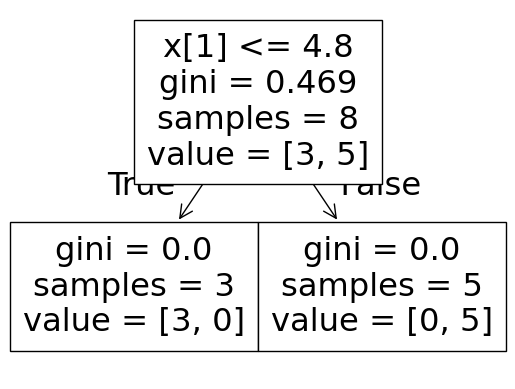

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


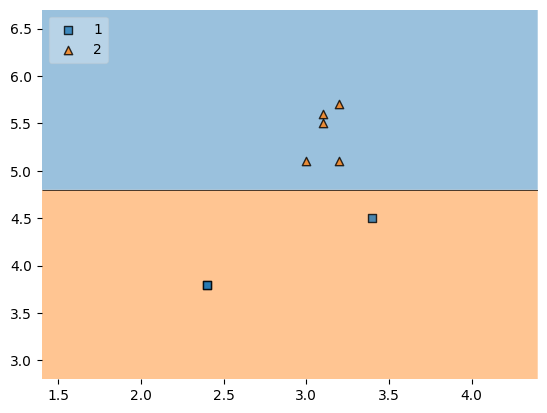

In [19]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [20]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Case 2: Pasting

In [21]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
69,2.5,3.9,1
64,2.9,3.6,1
140,3.1,5.6,2
80,2.4,3.8,1
110,3.2,5.1,2
120,3.2,5.7,2
149,3.0,5.1,2
82,2.7,3.9,1
137,3.1,5.5,2
85,3.4,4.5,1


In [22]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
137,3.1,5.5,2
85,3.4,4.5,1
120,3.2,5.7,2
82,2.7,3.9,1
140,3.1,5.6,2
110,3.2,5.1,2
64,2.9,3.6,1
149,3.0,5.1,2


# Case 3: Random Subspaces

In [23]:
df1 = pd.read_csv('/kaggle/input/datasets/uciml/iris/Iris.csv',
                usecols=lambda column: column not in ["Id"])
df1 = df1.sample(10)
df1.head(10)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
143,6.8,3.2,5.9,2.3,Iris-virginica
80,5.5,2.4,3.8,1.1,Iris-versicolor
149,5.9,3.0,5.1,1.8,Iris-virginica
144,6.7,3.3,5.7,2.5,Iris-virginica
40,5.0,3.5,1.3,0.3,Iris-setosa
21,5.1,3.7,1.5,0.4,Iris-setosa
104,6.5,3.0,5.8,2.2,Iris-virginica
46,5.1,3.8,1.6,0.2,Iris-setosa
131,7.9,3.8,6.4,2.0,Iris-virginica
87,6.3,2.3,4.4,1.3,Iris-versicolor


In [24]:
df1.sample(2,replace=True,axis=1)

,SepalLengthCm,Species
143,6.8,Iris-virginica
80,5.5,Iris-versicolor
149,5.9,Iris-virginica
144,6.7,Iris-virginica
40,5.0,Iris-setosa
21,5.1,Iris-setosa
104,6.5,Iris-virginica
46,5.1,Iris-setosa
131,7.9,Iris-virginica
87,6.3,Iris-versicolor


# Case 4: Random Patches

In [25]:
df1

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
143,6.8,3.2,5.9,2.3,Iris-virginica
80,5.5,2.4,3.8,1.1,Iris-versicolor
149,5.9,3.0,5.1,1.8,Iris-virginica
144,6.7,3.3,5.7,2.5,Iris-virginica
40,5.0,3.5,1.3,0.3,Iris-setosa
21,5.1,3.7,1.5,0.4,Iris-setosa
104,6.5,3.0,5.8,2.2,Iris-virginica
46,5.1,3.8,1.6,0.2,Iris-setosa
131,7.9,3.8,6.4,2.0,Iris-virginica
87,6.3,2.3,4.4,1.3,Iris-versicolor


In [26]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,SepalLengthCm,Species
143,6.8,Iris-virginica
21,5.1,Iris-setosa
144,6.7,Iris-virginica
21,5.1,Iris-setosa
149,5.9,Iris-virginica
80,5.5,Iris-versicolor
21,5.1,Iris-setosa
143,6.8,Iris-virginica


# Bagging in `scikit-learn`

In [27]:
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [28]:
X, y = make_classification(n_samples=10000, n_features=10, n_informative=3)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [30]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("Decision Tree accuracy", accuracy_score(y_test,y_pred))

Decision Tree accuracy 0.9284


## Bagging

In [31]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.5,
    bootstrap=True,
    random_state=42
)

* `max_samples=0.5`: Instructs the classifier to train each individual decision tree on only **50% of the total available training rows**.

* `bootstrap=True`: Enables **bootstrapping**, meaning rows are sampled **with replacement**. A single row can be selected multiple times for the same tree, while others might be left out entirely

In [32]:
bag.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.5,
                  n_estimators=500, random_state=42)

In [33]:
y_pred = bag.predict(X_test)

accuracy_score(y_test,y_pred)

0.9548

In [34]:
bag.estimators_samples_[0].shape

(3750,)

In [35]:
bag.estimators_features_[0].shape

(10,)

# Bagging using SVM

In [36]:
bag1 = BaggingClassifier(
    estimator=SVC(),
    n_estimators=100,
    max_samples=0.5,
    bootstrap=True,
    random_state=42
)

In [37]:
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
print("Bagging using SVM",accuracy_score(y_test,y_pred))

Bagging using SVM 0.9548


## Pasting

In [38]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.25,
    bootstrap=False,
    random_state=42,
    verbose = 1,
    n_jobs=-1
)

In [39]:
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
print("Pasting classifier",accuracy_score(y_test,y_pred))

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Pasting classifier 0.952


[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:    4.1s remaining:    4.1s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:    4.1s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:    0.1s finished


## Random Subspaces

In [40]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=1.0,
    bootstrap=False,
    max_features=0.5,
    bootstrap_features=True,
    random_state=42
)

In [41]:
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
print("Random Subspaces classifier",accuracy_score(y_test,y_pred))

Random Subspaces classifier 0.9416


## Random Patches

In [42]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    max_features=0.5,
    bootstrap_features=True,
    random_state=42
)

In [43]:
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
print("Random Patches classifier",accuracy_score(y_test,y_pred))

Random Patches classifier 0.9332


## OOB Score

In [44]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    oob_score=True,
    random_state=42
)
     

In [45]:
bag.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.25,
                  n_estimators=500, oob_score=True, random_state=42)

In [46]:
bag.oob_score_

0.9452

# Bagging Tips

* Bagging generally gives better results than Pasting

* Good results come around the 25% to 50% row sampling mark

* Random patches and subspaces should be used while dealing with high dimensional data

* To find the correct hyperparameter values we can do GridSearchCV/RandomSearchCV

# Applying GridSearchCV

In [47]:
'''
from sklearn.model_selection import GridSearchCV
     

parameters = {
    'n_estimators': [50,100,500], 
    'max_samples': [0.1,0.4,0.7,1.0],
    'bootstrap' : [True,False],
    'max_features' : [0.1,0.4,0.7,1.0]
    }
     

search = GridSearchCV(BaggingClassifier(n_jobs=-1), parameters, cv=5, n_jobs=-1, verbose=1)
     

search.fit(X_train,y_train)
'''

"\nfrom sklearn.model_selection import GridSearchCV\n     \n\nparameters = {\n    'n_estimators': [50,100,500], \n    'max_samples': [0.1,0.4,0.7,1.0],\n    'bootstrap' : [True,False],\n    'max_features' : [0.1,0.4,0.7,1.0]\n    }\n     \n\nsearch = GridSearchCV(BaggingClassifier(n_jobs=-1), parameters, cv=5, n_jobs=-1, verbose=1)\n     \n\nsearch.fit(X_train,y_train)\n"

In [48]:
#search.best_params_

In [49]:
#search.best_score_

In [50]:
from sklearn.datasets import fetch_california_housing

In [51]:
houses = fetch_california_housing()
X_houses, Y_houses = houses.data, houses.target

print('Dataset features names : '+ str(houses.feature_names))
print('Dataset features size : '+ str(houses.data.shape))
print('Dataset target size : '+ str(houses.target.shape))

Dataset features names : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Dataset features size : (20640, 8)
Dataset target size : (20640,)


In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_houses, Y_houses , train_size=0.80, test_size=0.20, random_state=123)
print('Train/Test Sets Sizes : ',X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

Train/Test Sets Sizes :  (16512, 8) (4128, 8) (16512,) (4128,)


In [56]:
lr = LinearRegression()
dt = DecisionTreeRegressor()
knn = KNeighborsRegressor()
     

lr.fit(X_train,Y_train)
dt.fit(X_train,Y_train)
knn.fit(X_train,Y_train)

KNeighborsRegressor()

In [57]:
y_pred1 = lr.predict(X_test)
y_pred2 = dt.predict(X_test)
y_pred3 = knn.predict(X_test)
     

print("R^2 score for LR",r2_score(Y_test,y_pred1))
print("R^2 score for DT",r2_score(Y_test,y_pred2))
print("R^2 score for KNN",r2_score(Y_test,y_pred3))

R^2 score for LR 0.6104546894797869
R^2 score for DT 0.6037369775422339
R^2 score for KNN 0.16261917827057237


In [58]:
from sklearn.ensemble import BaggingRegressor

bag_regressor = BaggingRegressor(random_state=1)
bag_regressor.fit(X_train, Y_train)

BaggingRegressor(random_state=1)

In [59]:
Y_preds = bag_regressor.predict(X_test)

print('Training Coefficient of R^2 : %.3f'%bag_regressor.score(X_train, Y_train))
print('Test Coefficient of R^2 : %.3f'%bag_regressor.score(X_test, Y_test))

Training Coefficient of R^2 : 0.963
Test Coefficient of R^2 : 0.792


In [61]:
%%time

n_samples = houses.data.shape[0]
n_features = houses.data.shape[1]

params = {'estimator': [None, LinearRegression(), KNeighborsRegressor()],
          'n_estimators': [20,50,100],
          'max_samples': [0.5,1.0],
          'max_features': [0.5,1.0],
          'bootstrap': [True, False],
          'bootstrap_features': [True, False]}

bagging_regressor_grid = GridSearchCV(BaggingRegressor(random_state=1, n_jobs=-1), param_grid =params, cv=3, n_jobs=-1, verbose=1)
bagging_regressor_grid.fit(X_train, Y_train)

print('Train R^2 Score : %.3f'%bagging_regressor_grid.best_estimator_.score(X_train, Y_train))
print('Test R^2 Score : %.3f'%bagging_regressor_grid.best_estimator_.score(X_test, Y_test))
print('Best R^2 Score Through Grid Search : %.3f'%bagging_regressor_grid.best_score_)
print('Best Parameters : ',bagging_regressor_grid.best_params_)

Fitting 3 folds for each of 144 candidates, totalling 432 fits


KeyboardInterrupt: 